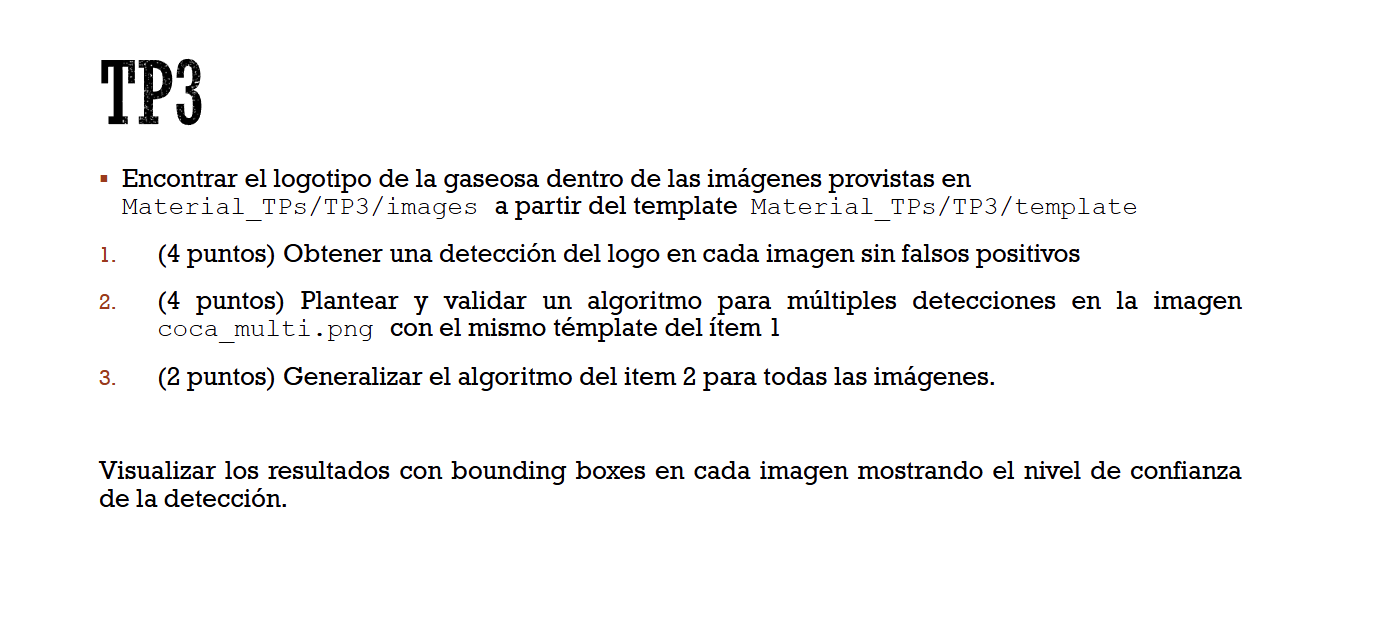

In [60]:
%matplotlib inline

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from pathlib import Path


Vamos a hacer una prueba inicial con el template y con la primera imagen

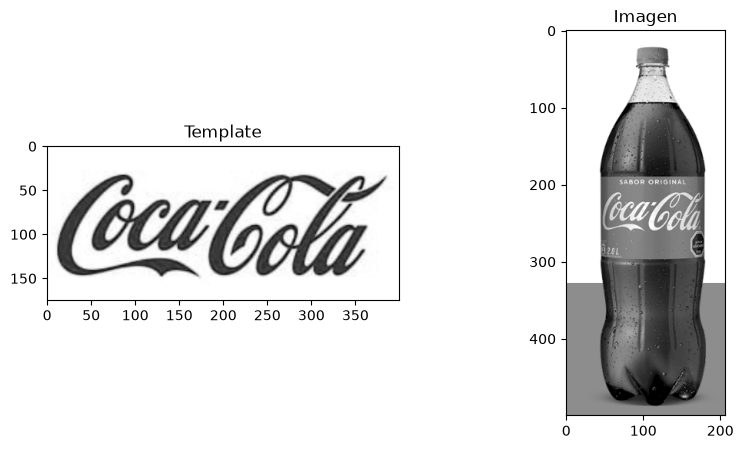

In [61]:
template = cv.imread("template/pattern.png", cv.IMREAD_GRAYSCALE)
imagen = cv.imread("images/coca_logo_1.png", cv.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(template, cmap="gray")
axes[0].set_title("Template")
axes[1].imshow(imagen, cmap="gray")
axes[1].set_title("Imagen")
plt.show()

Lo primero que podemos observar, es que el template tiene un fondo blanco con letras oscuras, mientras que la etiqueta contiene el fondo oscuro con las letras blancas. Pero si vemos este otro caso:

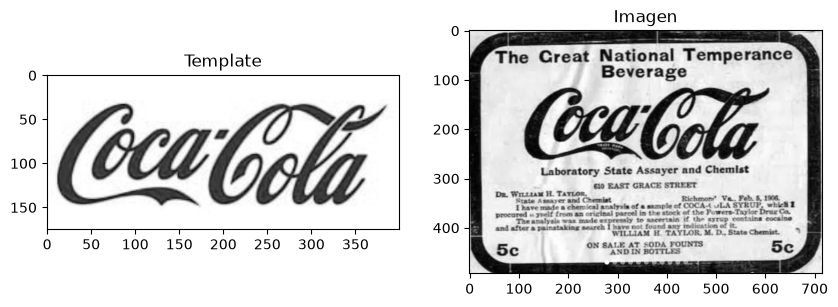

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(template, cmap="gray")
axes[0].set_title("Template")
axes[1].imshow(cv.imread("images/coca_retro_1.png", cv.IMREAD_GRAYSCALE), cmap="gray")
axes[1].set_title("Imagen")
plt.show()

En este caso parece haber un mejor match entre el template y la imagen objetivo. Este será el primer obstáculo a tener en cuenta, para poder generalizar, hay que ser capaces de poder utilizar el template y su invertido para cada caso.

Para empezar, voy a proponer un tamaño de template aleatorio para la primera imagen, y vamos a probar con el template común y con el que tiene los colores invertidos. Como la imagen objetivo tiene un ancho de aproximado 200 píxeles, voy a usar un ancho de 130 píxeles para mi template

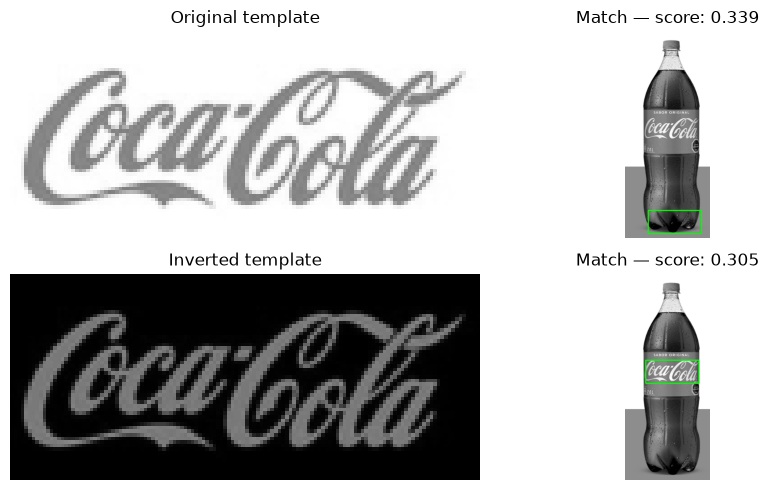

In [63]:
image = cv.imread("images/coca_logo_1.png", cv.IMREAD_GRAYSCALE)

width = 130
height = round(template.shape[0] * width / template.shape[1])

fig, axes = plt.subplots(2, 2, figsize=(10, 5))

for row, (label, source) in enumerate([
    ("Original", template),
    ("Inverted", cv.bitwise_not(template)),
]):
    pattern = cv.resize(
        source, (width, height), interpolation=cv.INTER_AREA
    )

    response = cv.matchTemplate(image, pattern, cv.TM_CCOEFF_NORMED)
    _, score, _, (x, y) = cv.minMaxLoc(response)

    output = cv.cvtColor(image, cv.COLOR_GRAY2RGB)
    cv.rectangle(
        output,
        (x, y),
        (x + width - 1, y + height - 1),
        (0, 255, 0),
        2,
    )

    axes[row, 0].imshow(pattern, cmap="gray", vmin=0, vmax=255)
    axes[row, 0].set_title(f"{label} template")

    axes[row, 1].imshow(output)
    axes[row, 1].set_title(f"Match — score: {score:.3f}")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

Se confirma la sospecha, se obtuvo un mejor match a partir de hacer la inversión de colores. Apliquémoslo a la imagen retro ahora. Acá la imagen destino tiene 600 píxeles de ancho, por lo que usaré un template de 480.

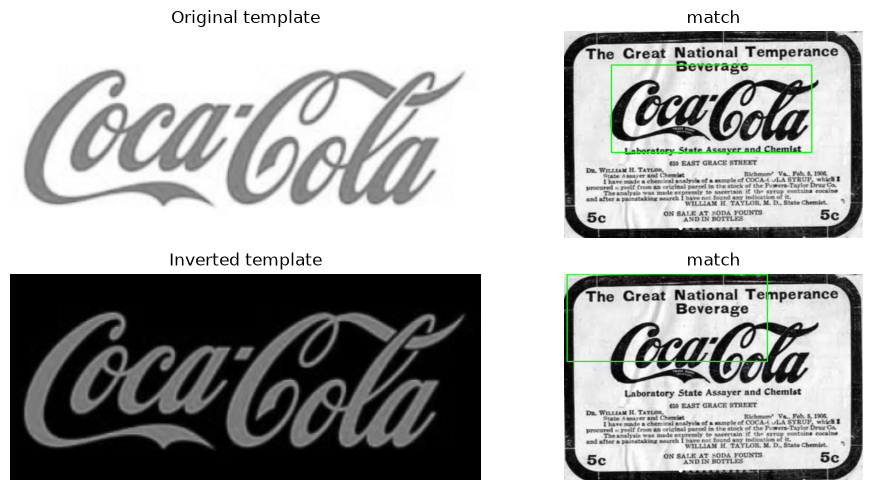

In [64]:
image = cv.imread("images/coca_retro_1.png", cv.IMREAD_GRAYSCALE)

width = 480
height = round(template.shape[0] * width / template.shape[1])

fig, axes = plt.subplots(2, 2, figsize=(10, 5))

for row, (label, source) in enumerate([
    ("Original", template),
    ("Inverted", cv.bitwise_not(template)),
]):
    pattern = cv.resize(
        source, (width, height), interpolation=cv.INTER_AREA
    )

    response = cv.matchTemplate(image, pattern, cv.TM_CCOEFF_NORMED)
    _, score, _, (x, y) = cv.minMaxLoc(response)

    output = cv.cvtColor(image, cv.COLOR_GRAY2RGB)
    cv.rectangle(
        output,
        (x, y),
        (x + width - 1, y + height - 1),
        (0, 255, 0),
        2,
    )

    axes[row, 0].imshow(pattern, cmap="gray", vmin=0, vmax=255)
    axes[row, 0].set_title(f"{label} template")

    axes[row, 1].imshow(output)
    axes[row, 1].set_title("match")

for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

Se observa que ahora, el template sin invertir tuvo un mejor matcheo, pero esto es dependiente de del ancho y el alto del template, dado que para distintos tamaños, podría haber puntos con mejor métricas que no necesariamente sean el logo que estamos buscando. En el primer intento con la botella, se puede observar que hubo un score mejor para una sección que ni siquiera tuvo el logo embebido, en cambio para la sección con el logo se obtuvo menos métrica. Seguramente, si se intentase con algún algoritmo que pruebe distintos anchos y altos, se pueda conseguir un algoritmo capaz de inferir el mejor template una imagen, pero de todas formas algo que también juega en contra es la curvatura de las etiquetas. Lo que podría favorecer esta última problemática, sería el cálculo de descriptores y aproximaciones de un objeto en otra imagen

Primero me traigo todas las imagenes donde quiero encontrar el logo

In [65]:

paths = sorted(
    path for path in Path("images").iterdir()
    if path.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp", ".webp"}
)

images = [
    cv.imread(str(path), cv.IMREAD_GRAYSCALE)
    for path in paths
]

Ahora que vemos todas las imagenes, reconfirmo un poco el hecho de usar template matching, tenemos imagenes de distinto ancho, distinto alto, algunos casos de color invertido y casos de curvatura en la etiqueta. Si bien template hubiese sido un buen approach, generalizarlo hubiese complejizado la búsqueda. Como dije anteriormente, me convence más la búsqueda de puntos característicos en el template, conseguir sus descriptores y buscar la comparativa en las imagenes objetivo.

Para la obtención de los descriptores, voy a utilizar SIFT

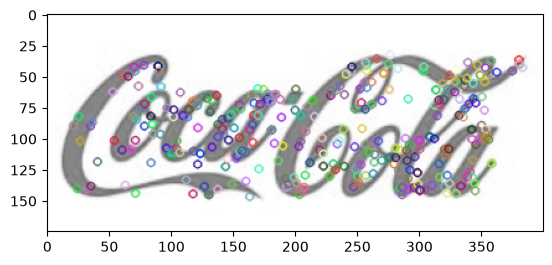

In [66]:
sift = cv.SIFT_create(contrastThreshold=0.015, edgeThreshold=15)
kp_template, des_template = sift.detectAndCompute(template, None)
assert des_template is not None and len(des_template) >= 2

points = cv.drawKeypoints(template, kp_template, None)
plt.imshow(cv.cvtColor(points, cv.COLOR_BGR2RGB))
plt.show()


Me voy a crear una función para poder buscar correspondencias entre el template y la imagen objetivo.

In [67]:
def find_matches(gray, invert=False):
    factor = 2.0 if max(gray.shape) < 1000 else 1.0
    scene = cv.resize(gray, None, fx=factor, fy=factor)
    if invert:
        scene = 255 - scene
    kp_scene, des_scene = sift.detectAndCompute(scene, None)
    if des_scene is None:
        return None
    # Busco los pares partiendo de la imagen objetivo hacia el template (esto por si hay más de un logo en una imagen)
    pairs = cv.BFMatcher(cv.NORM_L2).knnMatch(des_scene, des_template, k=2)
    good_matches = [
        pair[0] for pair in pairs
        if len(pair) == 2 and pair[0].distance < 0.75 * pair[1].distance
    ]
    if len(good_matches) < 7:
        return None

    source = np.float32([kp_template[m.trainIdx].pt for m in good_matches])
    destination = np.float32([kp_scene[m.queryIdx].pt for m in good_matches]) / factor
    scales = np.array([
        kp_scene[m.queryIdx].size / kp_template[m.trainIdx].size / factor
        for m in good_matches
    ])
    angles = np.radians([
        kp_scene[m.queryIdx].angle - kp_template[m.trainIdx].angle
        for m in good_matches
    ])
    distances = np.array([m.distance for m in good_matches])
    return source, destination, scales, angles, distances

Hago una prueba con una imagen

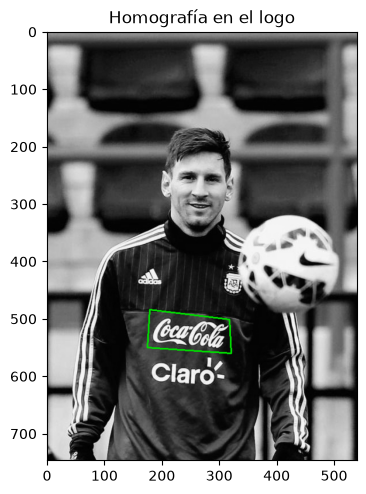

In [68]:
def find_homografy(image, invert=False):
    matches = find_matches(image, invert)

    source, destination, _, _, _ = matches

    H, _ = cv.findHomography(source, destination, cv.RANSAC, 2.5)

    height, width = template.shape[:2]
    corners = np.float32([
        [0, 0],
        [0, height - 1],
        [width - 1, height - 1],
        [width - 1, 0]
    ]).reshape(-1, 1, 2)

    projected_corners = cv.perspectiveTransform(corners, H)

    output = cv.cvtColor(image, cv.COLOR_GRAY2BGR)
    cv.polylines(
        output,
        [np.int32(projected_corners)],
        isClosed=True,
        color=(0, 220, 0),
        thickness=2
    )

    return output


output = find_homografy(images[10], invert=True)
plt.figure(figsize=(4, 7))
plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
plt.title("Homografía en el logo")
plt.show()


Ahora aplico el algoritmo en todas mis imágenes para ver cómo se comporta

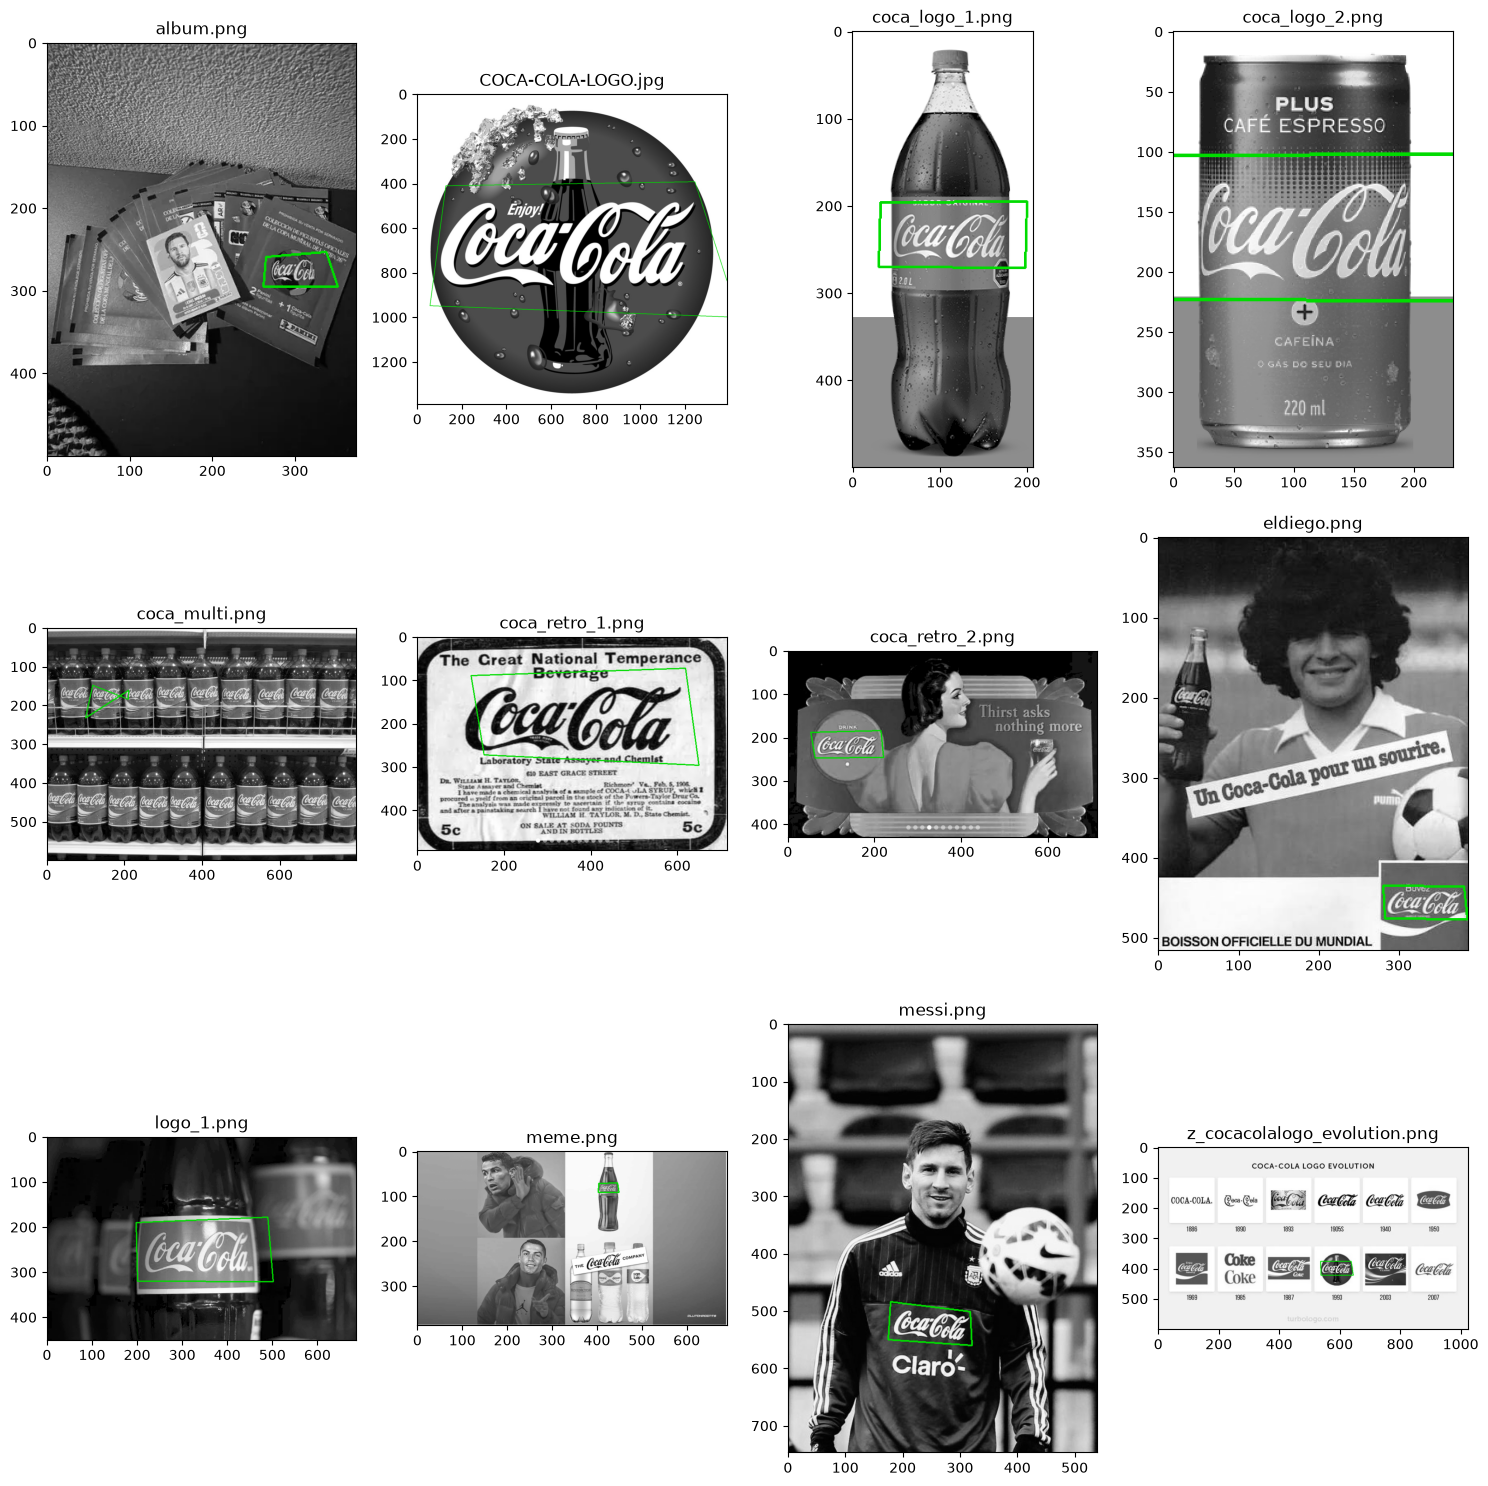

In [69]:
columns = 4
rows = (len(images) + columns - 1) // columns

fig, axes = plt.subplots(
    rows, columns, figsize=(15, 5 * rows), squeeze=False
)
for ax, image, path in zip(axes.flat, images, paths):
    ax.imshow(find_homografy(image, invert=False if path.name == "coca_retro_1.png" else True), cmap="gray")
    ax.set_title(path.name)

plt.tight_layout()
plt.show()


Si bien estoy pudiendo encontrar una homografía que contenga al logo embebido, si yo aplico este mismo algoritmo a una imagen con distintos logos, como se puede observar en el caso de multi, logo evolution, etc, no voy a poder encontrarlos todos. Además, en algunos casos engloba un poco más que solo el logo, o hace algunos macheos algo "extraños". Eso puede deberse a que el template contiene mucho fondo y debe querer machear también por todo ese fondo.

Para encontrar varios logos, primero voy a separar las correspondencias. Creo una función para que, a partir de la posición, escala y orientación de cada match estimo dónde estaría el centro del logo. Los matches que coincidan en esa ubicación probablemente pertenezcan al mismo logo.

In [70]:
def estimate_centers(source, destination, scales, angles):
    height, width = template.shape
    offset = np.array([width / 2, height / 2]) - source
    dx, dy = offset[:, 0], offset[:, 1]
    cos, sin = np.cos(angles), np.sin(angles)
    rotated = np.column_stack([cos * dx - sin * dy, sin * dx + cos * dy])
    return destination + scales[:, None] * rotated

Uso otsu para ajustar el box a las esquinas donde comienzan las letras, para poder tener un mejor template

In [71]:
_, mask = cv.threshold(template, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
x, y, w, h = cv.boundingRect(mask)
template_corners = np.float32([[x, y], [x+w, y], [x+w, y+h], [x, y+h]])

Calculo una homografía por grupo. Me quedo con las que tienen al menos 7 inliers, puntos repartidos por el template y una caja razonable. La confianza será la proporción de inliers del grupo; no es una probabilidad de acierto.

In [72]:
def estimate_detection(source, destination, shape):
    H, mask = cv.findHomography(source, destination, cv.RANSAC, 2.5)
    if H is None or mask is None:
        return None
    inliers = mask.ravel().astype(bool)
    points = source[inliers]
    if inliers.sum() < 7 or len(np.unique(np.round(points, 1), axis=0)) < 6:
        return None
    if cv.contourArea(cv.convexHull(points)) / template.size < 0.08:
        return None

    polygon = cv.perspectiveTransform(template_corners[None], H)[0]
    if not np.isfinite(polygon).all() or not cv.isContourConvex(polygon):
        return None
    x1, y1 = polygon.min(axis=0)
    x2, y2 = polygon.max(axis=0)
    w, h = x2-x1, y2-y1
    image_h, image_w = shape
    if not (w > 20 and h > 5 and 1.5 < w/h < 6 and w < 1.5*image_w):
        return None
    if cv.contourArea(polygon) / (w*h) < 0.55:
        return None
    if x1 < -0.3*w or y1 < -0.3*h or x2 > image_w+0.3*w or y2 > image_h+0.3*h:
        return None
    box = [max(0, x1), max(0, y1), min(image_w, x2), min(image_h, y2)]
    return {"box": box, "score": float(inliers.mean())}

Pruebo el contraste normal e invertido y agrupo los matches por centro, escala y orientación similares. A cada grupo le aplico la función anterior.

In [73]:
def find_candidates(image):
    cv.setRNGSeed(42)
    candidates = []
    for invert in [False, True]:
        matches = find_matches(image, invert)
        if matches is None:
            continue
        source, destination, scales, angles, distances = matches
        centers = estimate_centers(source, destination, scales, angles)
        seen = set()
        for i in np.argsort(distances):
            group = np.linalg.norm(centers - centers[i], axis=1) < 0.30*template.shape[1]*scales[i]
            group &= np.abs(np.log(scales / scales[i])) < 0.60
            group &= np.cos(angles - angles[i]) > 0.85
            indices = tuple(np.flatnonzero(group))
            if len(indices) < 7 or indices in seen:
                continue
            seen.add(indices)
            detection = estimate_detection(source[group], destination[group], image.shape)
            if detection is not None:
                candidates.append(detection)
    return candidates


Distintos grupos pueden detectar el mismo logo. Ordeno las cajas por confianza y
descarto las que se superponen demasiado con una ya elegida. Para medir esa
superposición uso IoU: área compartida dividida por el área de la unión.

In [74]:
def box_iou(a, b):
    left, top = max(a[0], b[0]), max(a[1], b[1])
    right, bottom = min(a[2], b[2]), min(a[3], b[3])
    intersection = max(0, right-left) * max(0, bottom-top)
    area_a = (a[2]-a[0]) * (a[3]-a[1])
    area_b = (b[2]-b[0]) * (b[3]-b[1])
    return intersection / max(area_a+area_b-intersection, 1e-9)

def remove_duplicates(candidates):
    selected = []
    for candidate in sorted(candidates, key=lambda d: d["score"], reverse=True):
        if all(box_iou(candidate["box"], other["box"]) < 0.25 for other in selected):
            selected.append(candidate)
    return selected

Creo una función para mostrar los macheos

In [75]:
def show_detections(image, detections, ax):
    output = cv.cvtColor(image, cv.COLOR_GRAY2RGB)
    ax.imshow(output)
    for d in detections:
        x1, y1, x2, y2 = np.rint(d["box"]).astype(int)
        ax.text(x1, max(y1 - 3, 8), f"{d['score']:.2f}", color="lime", fontsize=7, fontweight="bold",
        bbox=dict(facecolor="black", alpha=0.7, pad=1, edgecolor="none"))
        ax.add_patch(
            plt.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                fill=False,
                edgecolor="green",
                linewidth=1.3
            )
        )
    ax.axis("off")

Pruebo con "coca_multi.png"

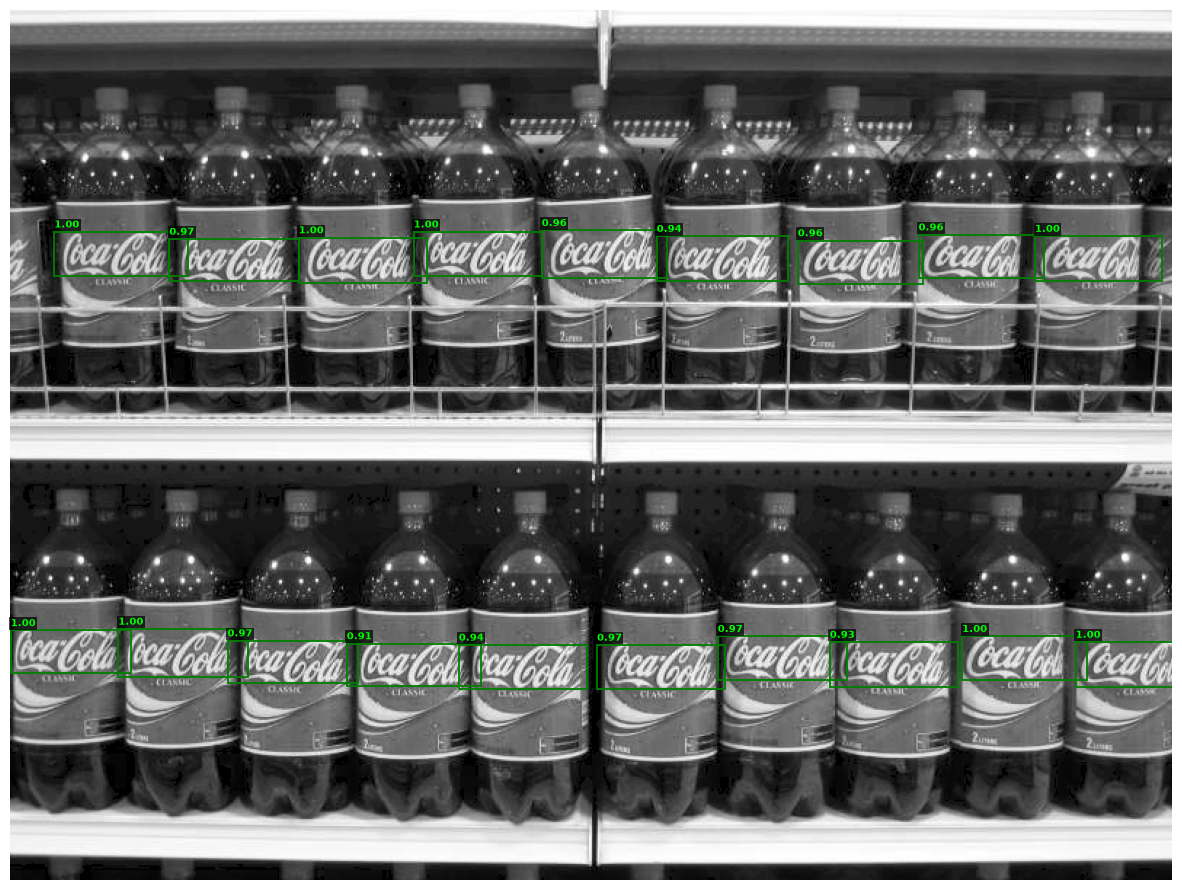

In [76]:
detections = remove_duplicates(
    find_candidates(images[4])
)

fig, ax = plt.subplots(figsize=(13, 9))

show_detections(
    images[4],
    detections,
    ax
)

plt.tight_layout()
plt.show()

En coca_multi.png se observo 19 botellas con logotipo visible, y el algoritmo las logró detectar. Esto permite validar la detección de múltiples instancias en una imagen dada

Lo aplico a todas las imágenes

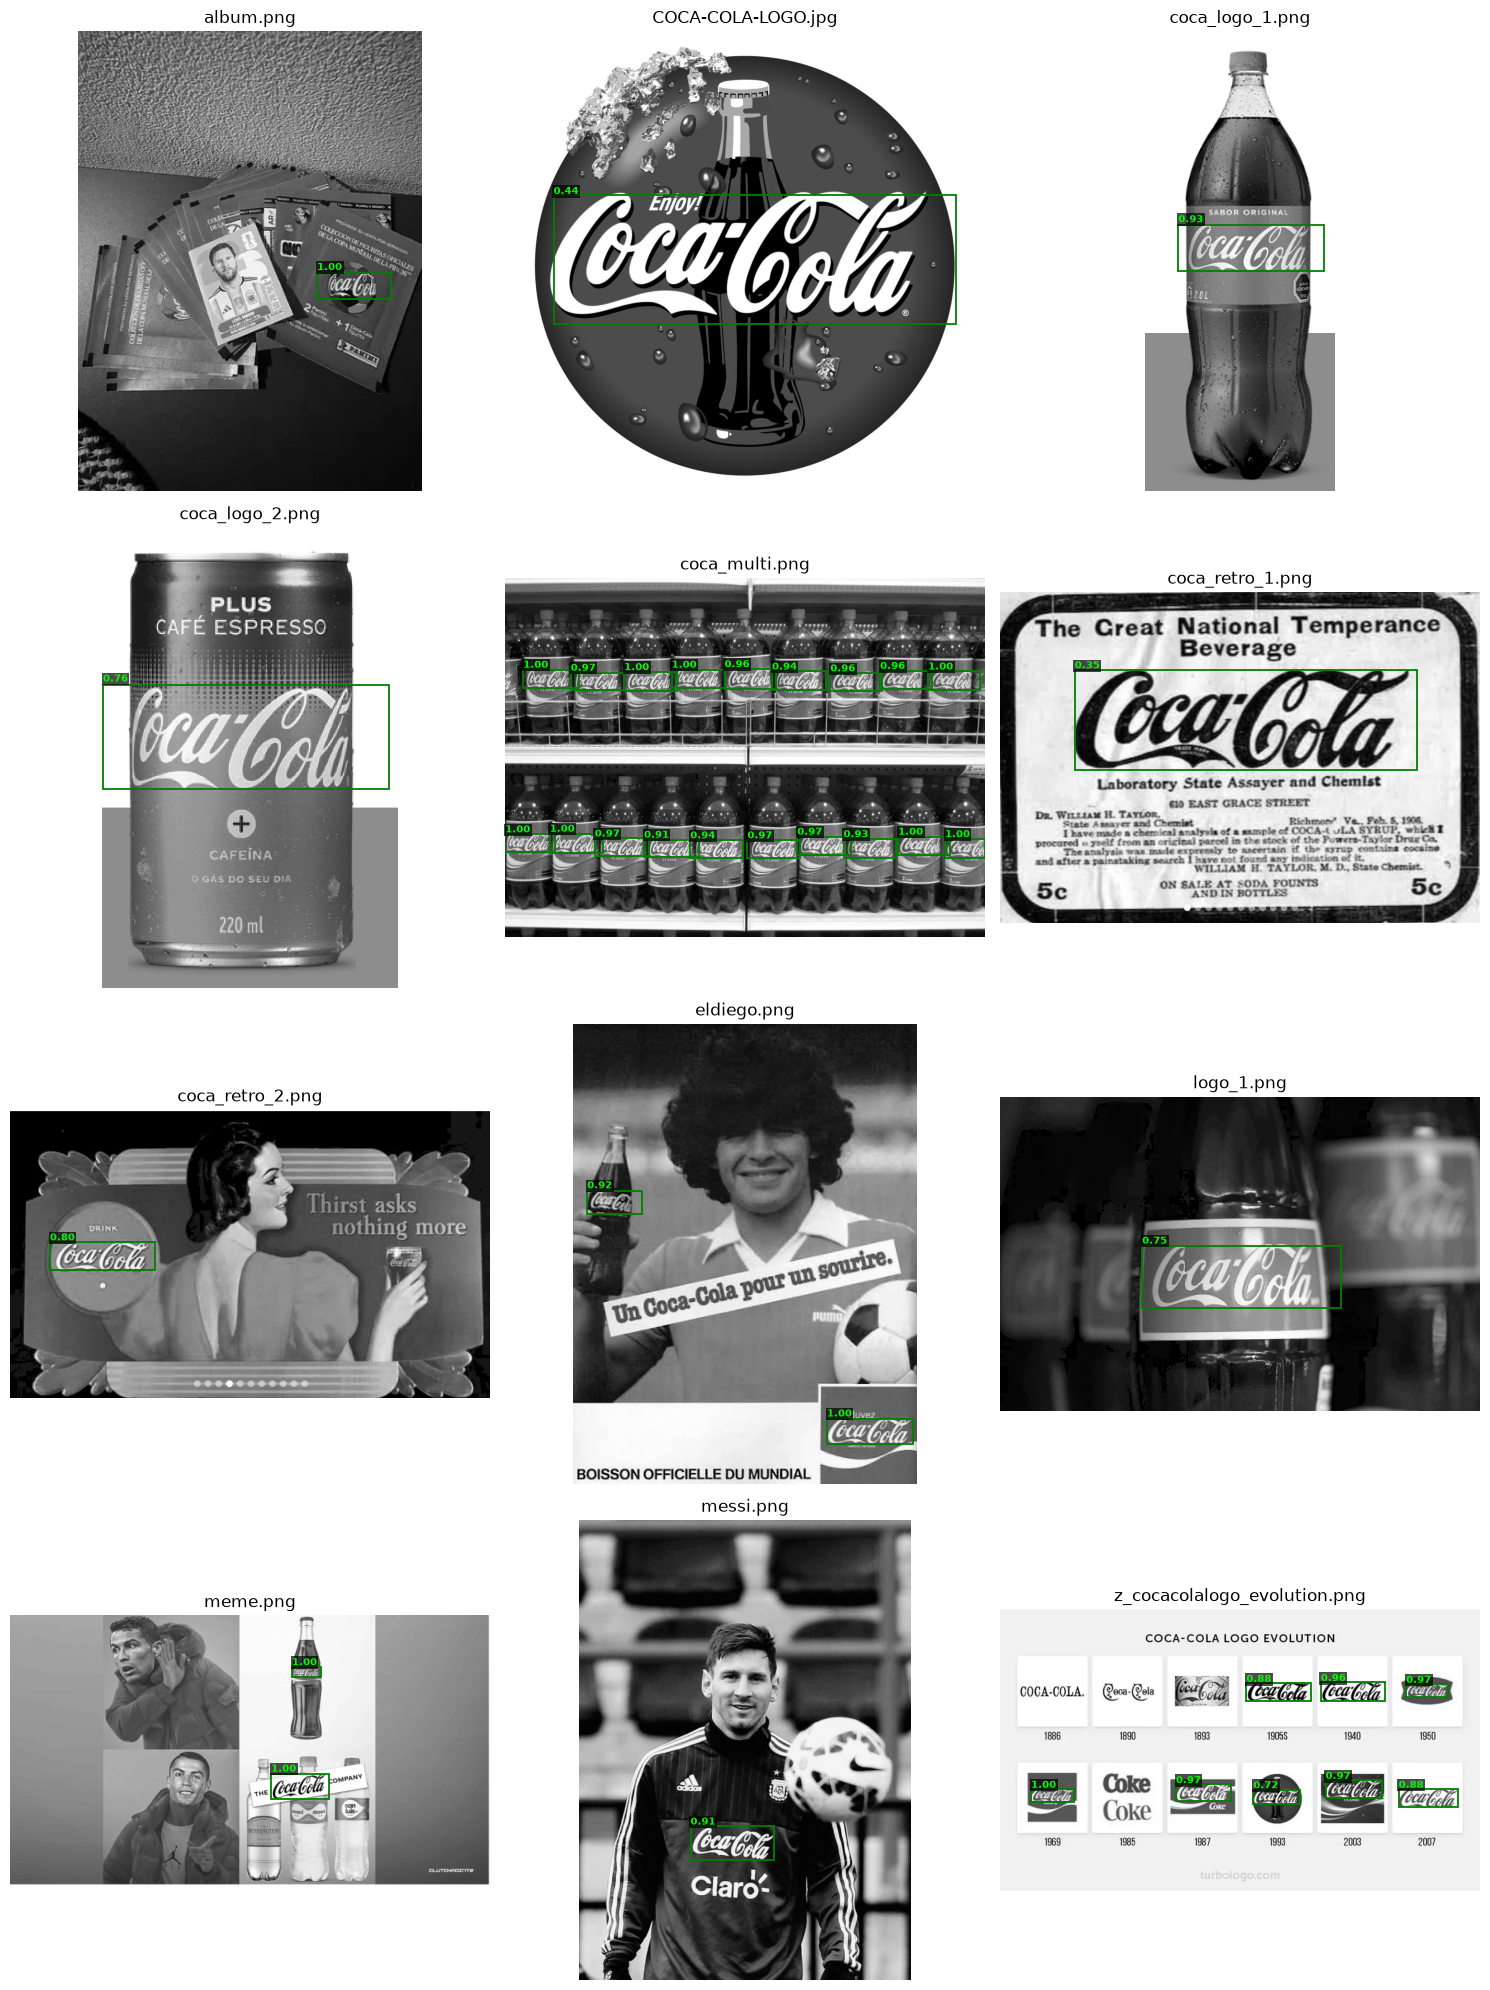

In [77]:
sift_results = [
    remove_duplicates(find_candidates(image))
    for image in images
]

columns = 3
rows = (len(images) + columns - 1) // columns

fig, axes = plt.subplots(
    rows, columns,
    figsize=(15, 5 * rows),
    squeeze=False
)
for image, detections, path, ax in zip(images, sift_results, paths, axes.flat):
    show_detections(image, detections, ax)
    ax.set_title(path.name)

for ax in list(axes.flat)[len(images):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


Al generalizar el algoritmo a todas las imágenes se obtienen detecciones correctas. Cabe destacar que en la imagen de evolución histórica algunos logotipos muy antiguos no son detectados, y esto tiene sentido ya que su estructura visual difiere del template proporcionado, por lo que no poseen suficientes puntos característicos compatibles para formar una homografía válida.